# Visual Localization: Override
Attempting localization on the VEX V5RC Override field using only a YOLO model with goal locations.

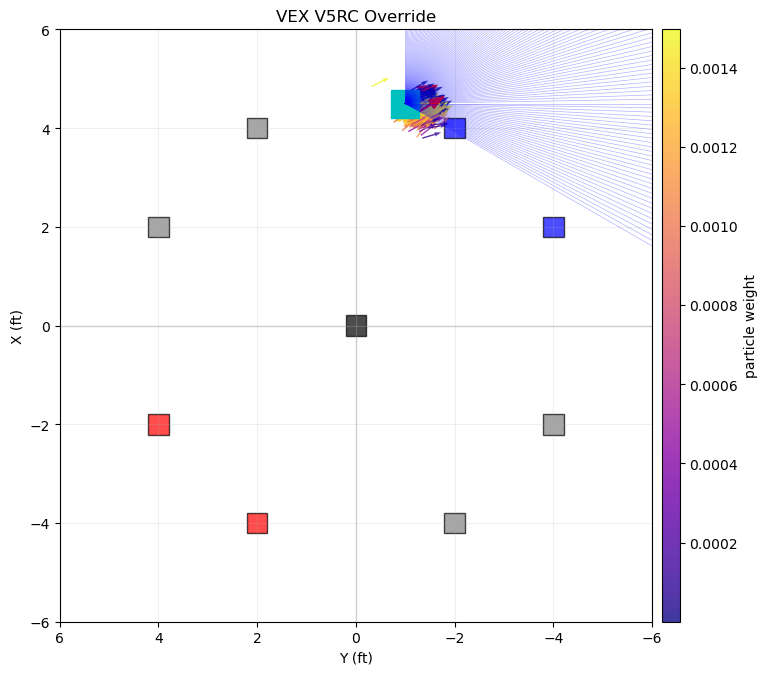

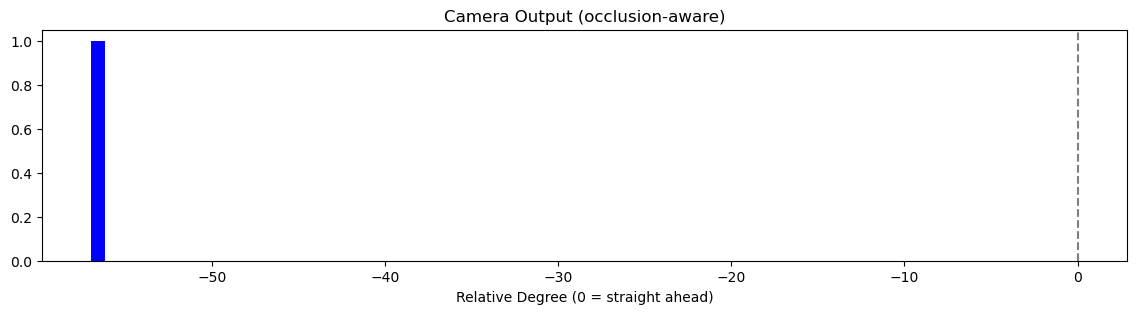

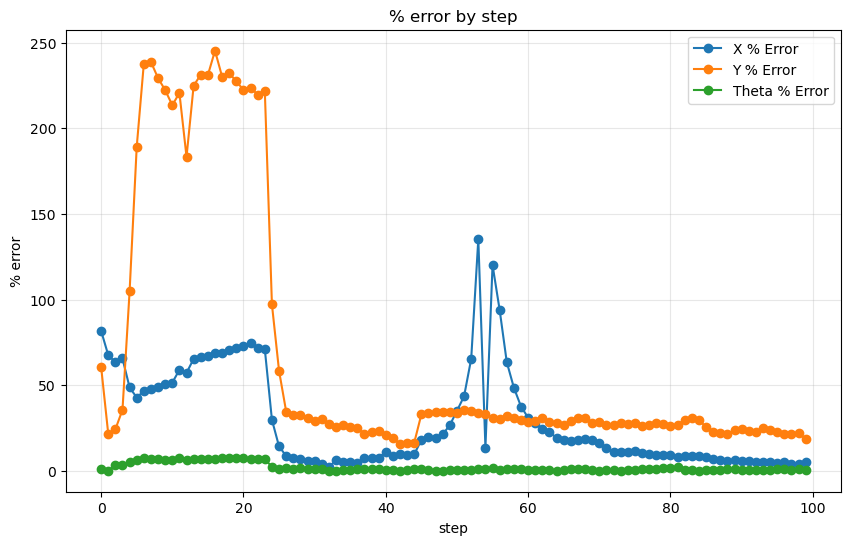

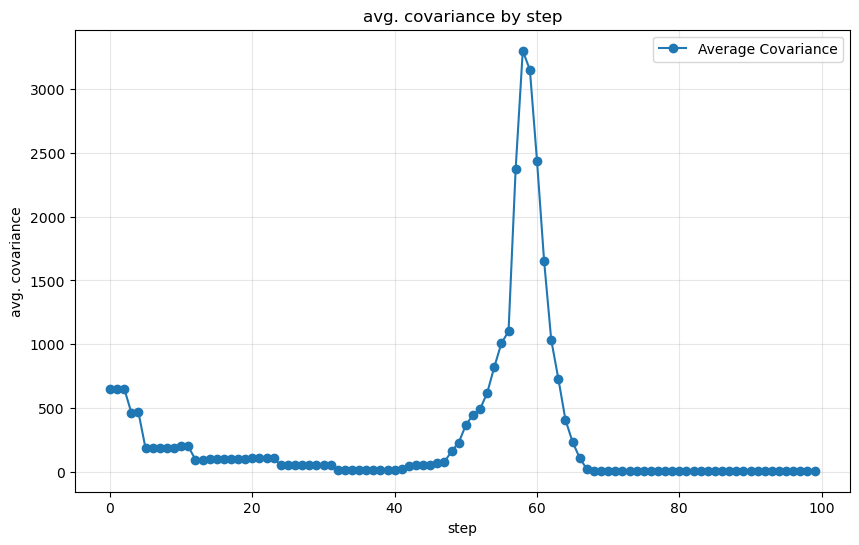

In [ ]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

from field import Field
from robot import Robot
from localize import Localize
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import pandas as pd
import time
from datetime import datetime
from utilities import percent_error, average_covariance

field = Field()
fig, ax = field.plot_base()

num_particles = 1000
log = False

loc = Localize(ax, field, max_particles=num_particles, random=False, debug=True)
loc.initial_draw(num_particles)

robot = Robot(-5.5, -1, 0, ax, field, debug=False)  # pass in goal locations through field

robot.draw_robot()
robot.camera.raycast()

log_rows = []
cycle_rows = []

for step in range(100):
    # move first, then get sensor reading
    dx, dy, dth = (0.1, 0, 3)
    odom = robot.drive_path(dx, dy, dth)
    obs = robot.camera.read()
    pose = loc.update((dx, dy, dth), obs)

    print(len(loc.particles))

    covariance = loc.calc_covariance()
    avg_covariance = average_covariance(covariance)
    
    true_x, true_y, true_th = robot.location
    est_x, est_y, est_th = pose # type: ignore 

    x_error = percent_error(est_x, true_x, true_x)
    y_error = percent_error(est_y, true_y, true_y)
    th_error = percent_error(((est_th - true_th + 180) % 360) - 180, 0.0, 360.0)

    cycle_ns = time.time_ns()
    cycle_rows.append({
        "step": step,
        "time_ns": cycle_ns,
        "timestamp": pd.to_datetime(cycle_ns, unit="ns", utc=True),
        "true_x": true_x,
        "true_y": true_y,
        "true_th": true_th,
        "est_x": est_x,
        "est_y": est_y,
        "est_th": est_th,
        "x_percent_error": x_error,
        "y_percent_error": y_error,
        "th_percent_error": th_error,
        "avg_covariance": avg_covariance,
    })

    if log:
        for i, (particle, weight, error) in enumerate(zip(loc.particles, loc.weights, loc.particle_errors)):
            logged_ns = time.time_ns()
            log_rows.append({
                "step": step,
                "particle": i,
                "time_ns": logged_ns,
                "timestamp": pd.to_datetime(logged_ns, unit="ns", utc=True),
                "x": particle[0],
                "y": particle[1],
                "theta": particle[2],
                "weight": weight,
                "error": error,
            })

    clear_output(wait=True)
    display(fig)
    plt.pause(0.1)

robot.camera.show_output()

cycle_df = pd.DataFrame(cycle_rows)

if log:
    particle_df = pd.DataFrame(log_rows)
    out_file = f"logs/particle_log_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    particle_df.to_csv(out_file, index=False)
    print(f"Saved particle log to {out_file}")

# plot error of estimated filter pose vs actual pose
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(cycle_df["step"], cycle_df["x_percent_error"], marker="o", label="X % Error")
ax2.plot(cycle_df["step"], cycle_df["y_percent_error"], marker="o", label="Y % Error")
ax2.plot(cycle_df["step"], cycle_df["th_percent_error"], marker="o", label="Theta % Error")
ax2.set_xlabel("step")
ax2.set_ylabel("% error")
ax2.set_title("% error by step")
ax2.grid(True, alpha=0.3)
ax2.legend()
display(fig2)
plt.close(fig2)

# plot average covariance
fig3, ax3 = plt.subplots(figsize=(10, 6))
ax3.plot(cycle_df["step"], cycle_df["avg_covariance"], marker="o", label="Average Covariance")
ax3.set_xlabel("step")
ax3.set_ylabel("avg. covariance")
ax3.set_title("avg. covariance by step")
ax3.grid(True, alpha=0.3)
ax3.legend()
display(fig3)
plt.close(fig3)

